In [3]:
import mne
import sys
import spikeinterface as si
import matplotlib.pyplot as plt
import spikeinterface.extractors as se
import spikeinterface.preprocessing as spre
import spikeinterface.sorters as ss
import spikeinterface.widgets as sw
import spikeinterface.qualitymetrics as sqm
import json
import probeinterface

from probeinterface import Probe, ProbeGroup

import os
import numpy as np
from spikeinterface.core import concatenate_recordings

import warnings
warnings.filterwarnings('ignore')
import pandas as pd
from matplotlib.backends.backend_pdf import PdfPages
import seaborn as sns

from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from scipy.stats import pearsonr
import pandas as pd
import numpy as np
from matplotlib.collections import LineCollection

In [ ]:
recording_raw = se.read_intan(f"/media/ubuntu/sda/cen/0912-麻醉觉醒PF记录/0912_250912_144124-麻醉状态10分钟/0912_250912_144124.rhs", stream_id= '0')
recording_raw = spre.unsigned_to_signed(recording_raw)
recording_recorded = recording_raw.remove_channels(['A-001', 'A-003', 'A-005', 'A-007', 'A-009', 'A-010', 'A-011', 'A-012', 'A-013', 'A-014', 'A-015', 'A-000'])
data = recording_recorded.get_traces()
#recording_recorded = spre.bandpass_filter(recording_recorded, freq_min=300, freq_max=3000)
#recording_recorded = spre.notch_filter(recording_recorded, freq=50)
#recording_f = spre.common_reference(recording_recorded, reference="global", operator="median")

In [15]:
# 获取基本信息
sfreq = recording_recorded.get_sampling_frequency()  # 采样率
print(f"采样率: {sfreq} Hz")
print(f"数据形状: {data.shape}")
print(f"通道数: {data.shape[0] if data.ndim == 2 else 'Unknown'}")
print(f"时间点数: {data.shape[1] if data.ndim == 2 else 'Unknown'}")

# 提取EEG数据（前两个通道）
eeg_data = data.T[:2, :]  # 形状: (2, n_time)
print(f"EEG数据形状: {eeg_data.shape}")

# 时间轴（秒）
times = np.arange(eeg_data.shape[1]) / sfreq
print(f"总时长: {times[-1]:.2f} 秒")


采样率: 30000.0 Hz
数据形状: (18000000, 4)
通道数: 18000000
时间点数: 4
EEG数据形状: (2, 18000000)
总时长: 600.00 秒


In [16]:
# 创建MNE Raw对象用于EEG分析
# 注意：MNE默认单位是V（伏特）
# 如果SpikeInterface返回的数据已经是V，则不需要转换
# 如果SpikeInterface返回的是μV或其他单位，需要相应调整
# 根据gain_to_uV信息（0.195），原始数据单位可能是ADC值，需要乘以gain转换为μV
# 这里假设data已经是μV单位，转换为V

# 检查数据单位：如果数值很大（>1000），可能是ADC值，需要转换
if np.abs(eeg_data).max() > 1000:
    print(f"警告: 数据最大值 {np.abs(eeg_data).max():.2f} 较大，可能需要检查单位")
    print("提示: 如果数据是ADC值，需要乘以gain转换为μV，再乘以1e-6转换为V")

# 转换为V（假设原始数据为μV）
eeg_data_v = eeg_data * 1e-6  # μV转换为V

# 创建info对象
ch_names = ['EEG_1', 'EEG_2']
ch_types = ['eeg', 'eeg']
info = mne.create_info(ch_names=ch_names, sfreq=sfreq, ch_types=ch_types)

# 创建Raw对象
raw_eeg = mne.io.RawArray(eeg_data_v, info)
print(raw_eeg)
print(f"\n通道信息: {raw_eeg.ch_names}")
print(f"数据范围: {eeg_data_v.min():.6e} V 到 {eeg_data_v.max():.6e} V")

# 可选：如果知道物理单位，可以设置通道位置（这里简单设置）
montage = None  # 可以根据实际情况设置montage


警告: 数据最大值 5923.00 较大，可能需要检查单位
提示: 如果数据是ADC值，需要乘以gain转换为μV，再乘以1e-6转换为V
Creating RawArray with float64 data, n_channels=2, n_times=18000000
    Range : 0 ... 17999999 =      0.000 ...   600.000 secs
Ready.
<RawArray | 2 x 18000000 (600.0 s), ~274.7 MiB, data loaded>

通道信息: ['EEG_1', 'EEG_2']
数据范围: -5.923000e-03 V 到 4.273000e-03 V


NOTE: tfr_morlet() is a legacy function. New code should use .compute_tfr(method="morlet").
inst is Evoked, setting `average=False`
No baseline correction applied
No baseline correction applied


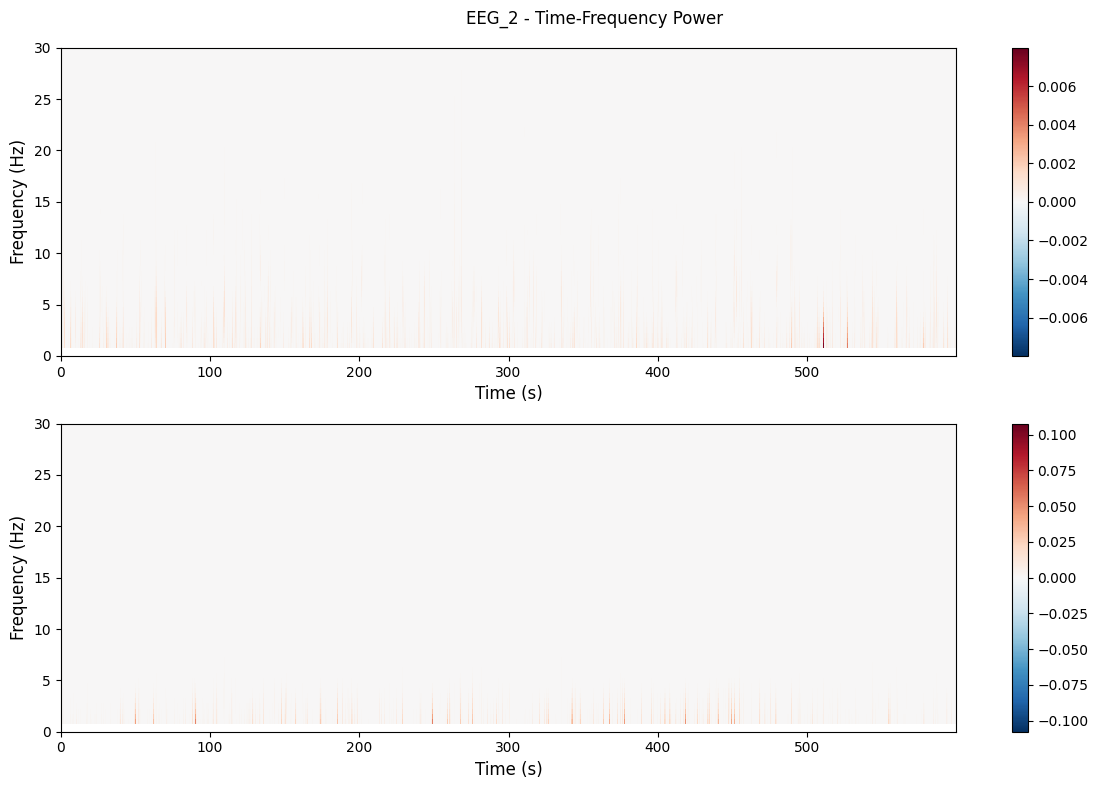

In [17]:
# 1. 计算Time-frequency spectra (时频谱) 并绘制热图 (0-30Hz)
from mne.time_frequency import tfr_morlet

# 定义频率范围：0-30 Hz
freqs = np.arange(1, 31, 0.5)  # 1-30 Hz，步长0.5 Hz
n_cycles = freqs / 2.0  # 每个频率的周期数

# 对所有EEG通道同时计算时频谱
power = tfr_morlet(raw_eeg, freqs=freqs, n_cycles=n_cycles, 
                   picks='eeg', use_fft=True, return_itc=False, 
                   decim=10, n_jobs=1)  # decim用于降采样加速

# 绘制热图
fig, axes = plt.subplots(2, 1, figsize=(12, 8))
fig.suptitle('EEG Time-Frequency Spectra (0-30 Hz)', fontsize=16, fontweight='bold')

for idx, ch_name in enumerate(ch_names):
    # 只绘制当前通道
    power.plot(axes=axes[idx], picks=[idx], colorbar=True, cmap='RdBu_r', 
               title=f'{ch_name} - Time-Frequency Power',
               show=False)
    
    # 设置y轴范围为0-30Hz
    axes[idx].set_ylim([0, 30])
    axes[idx].set_ylabel('Frequency (Hz)', fontsize=12)
    axes[idx].set_xlabel('Time (s)', fontsize=12)

plt.tight_layout()
plt.show()

# 保存功率谱数据以供后续使用
power_data = power  # 保存为变量


Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 0.5 - 4 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 0.50
- Lower transition bandwidth: 0.50 Hz (-6 dB cutoff frequency: 0.25 Hz)
- Upper passband edge: 4.00 Hz
- Upper transition bandwidth: 2.00 Hz (-6 dB cutoff frequency: 5.00 Hz)
- Filter length: 198001 samples (6.600 s)

Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 4 - 8 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 4.00
- Lower transition bandwidth: 2.00 Hz (-6 dB cutoff frequency: 3.00 Hz)
- Upper passband edge: 8

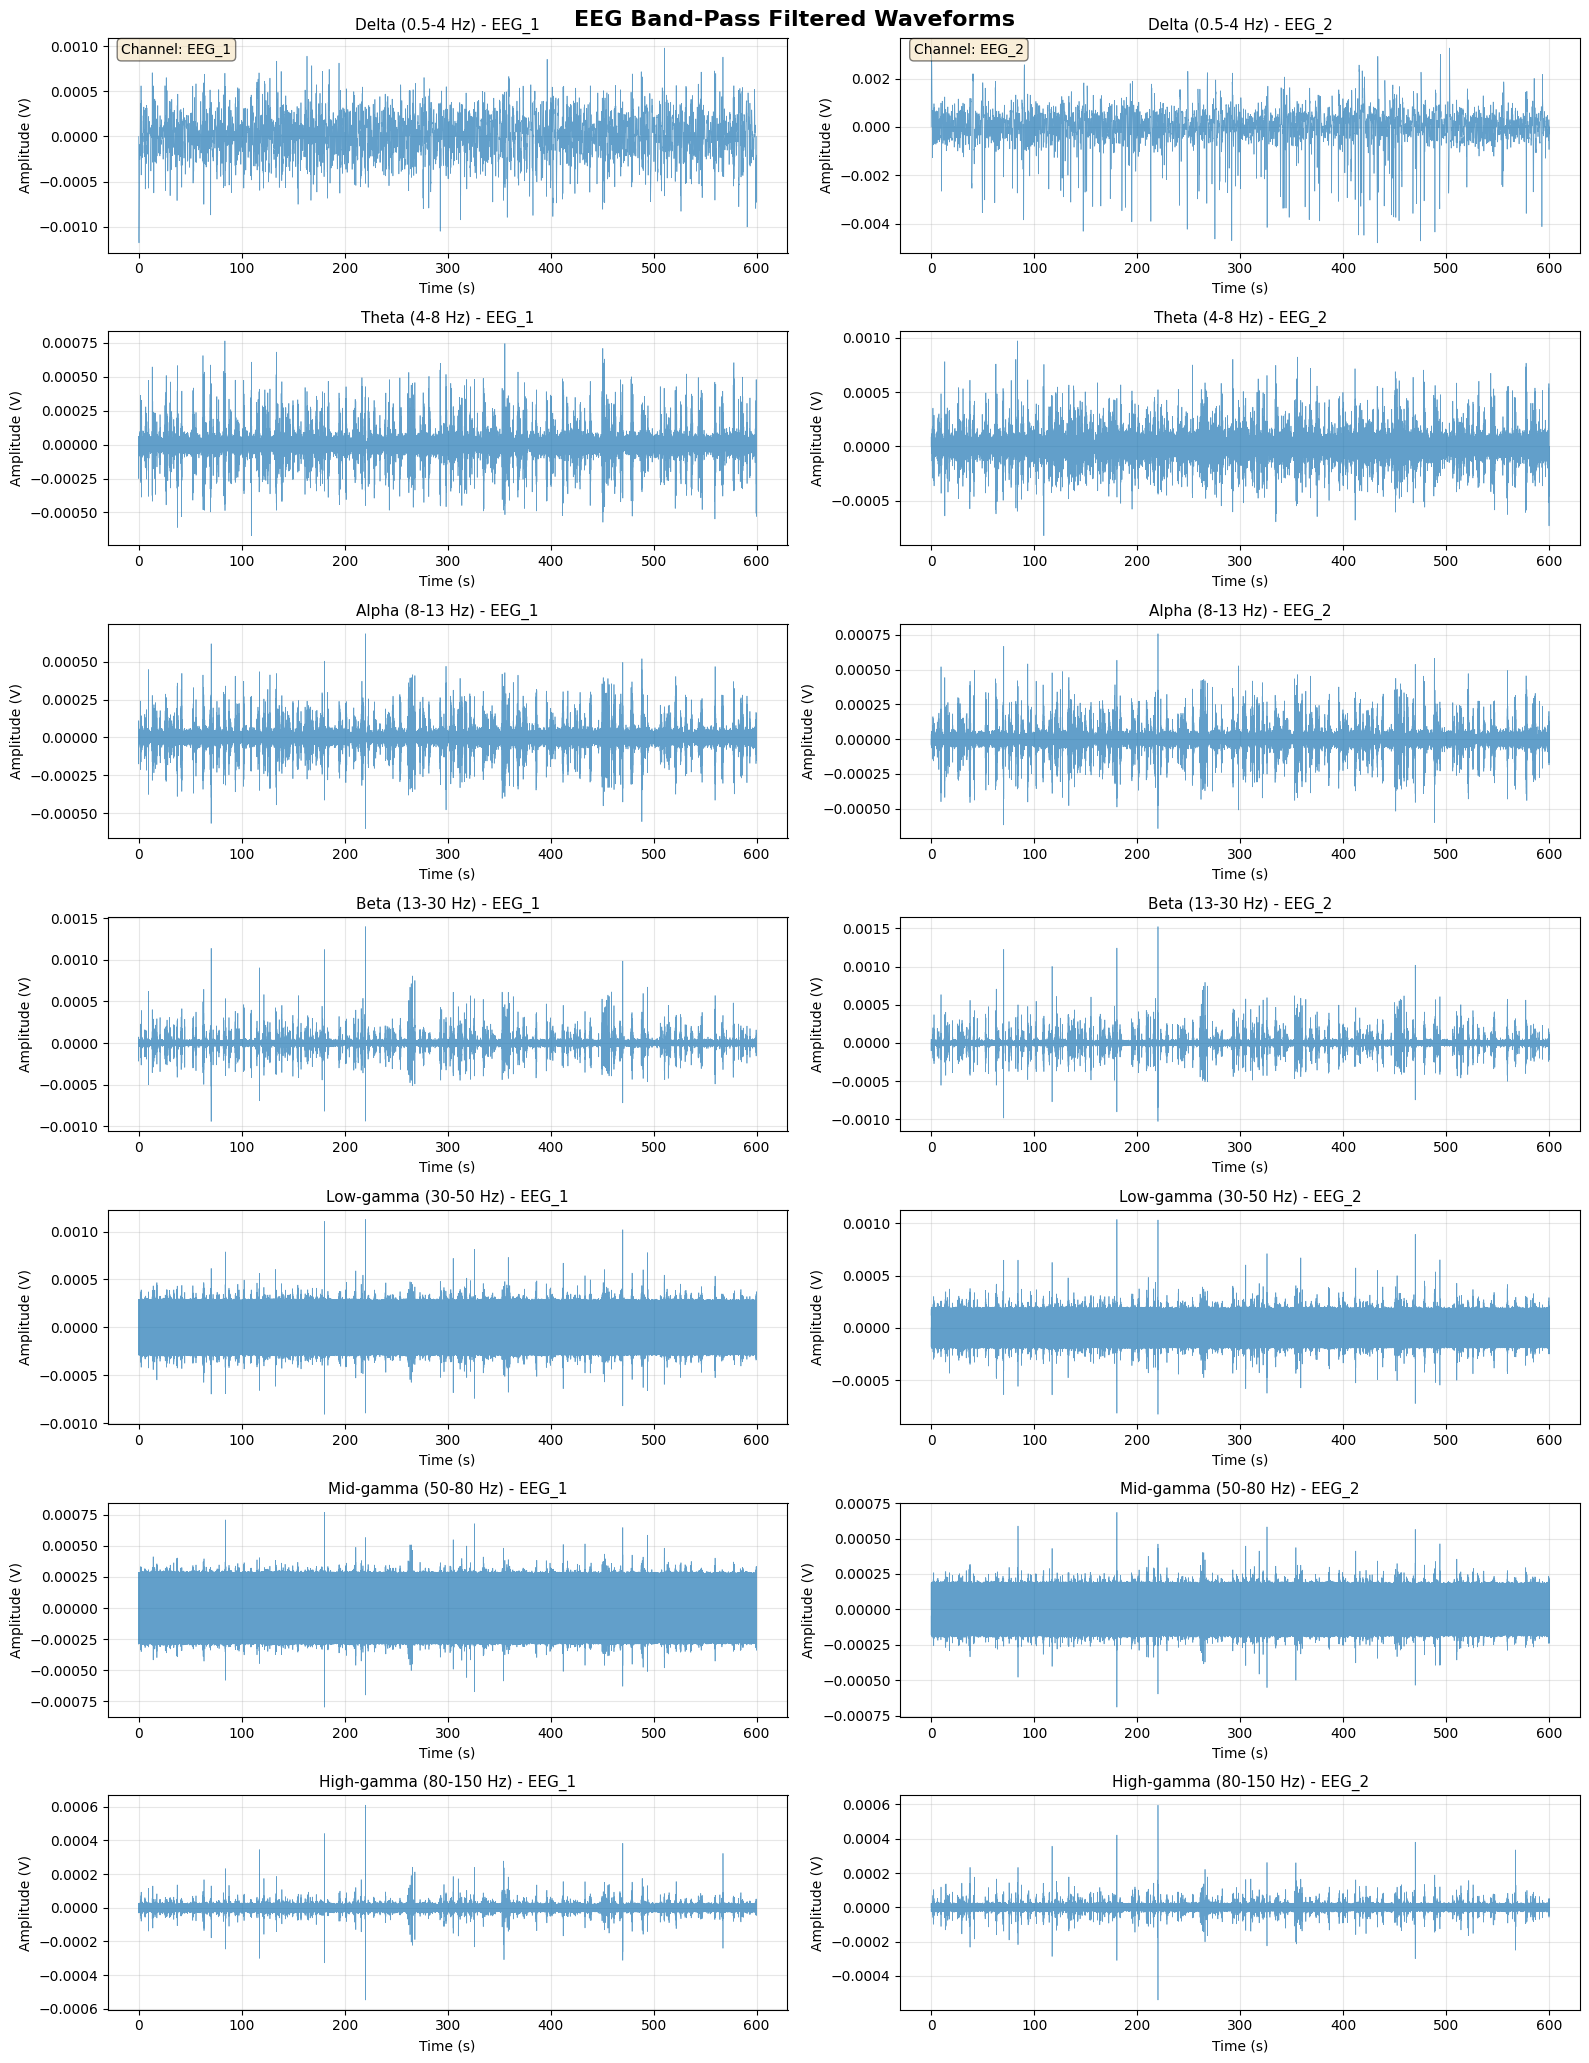


已提取以下频段的滤波数据: ['Delta', 'Theta', 'Alpha', 'Beta', 'Low-gamma', 'Mid-gamma', 'High-gamma']


In [22]:
# 2. 提取不同波段(Delta, Theta, Alpha, Beta, Low-gamma, Mid-gamma, High-gamma)的波形曲线
# 定义频段
bands = {
    'Delta': (0.5, 4),
    'Theta': (4, 8),
    'Alpha': (8, 13),
    'Beta': (13, 30),
    'Low-gamma': (30, 50),
    'Mid-gamma': (50, 80),
    'High-gamma': (80, 150)
}

# 存储滤波后的数据
band_filtered_data = {}

# 对每个频段进行带通滤波
fig, axes = plt.subplots(len(bands), 2, figsize=(16, 3 * len(bands)))
fig.suptitle('EEG Band-Pass Filtered Waveforms', fontsize=16, fontweight='bold')

for band_idx, (band_name, (fmin, fmax)) in enumerate(bands.items()):
    # 跳过超出采样率一半的频率（Nyquist频率）
    if fmax > sfreq / 2:
        print(f"警告: {band_name} 频段的最高频率 {fmax} Hz 超过了Nyquist频率 {sfreq/2:.1f} Hz，跳过该频段")
        continue
    
    # 创建滤波后的Raw对象副本
    raw_filtered = raw_eeg.copy()
    
    # 带通滤波
    raw_filtered.filter(l_freq=fmin, h_freq=fmax, picks='eeg', 
                       filter_length='auto', l_trans_bandwidth='auto', 
                       h_trans_bandwidth='auto', method='fir')
    
    # 获取滤波后的数据
    filtered_data = raw_filtered.get_data()
    
    # 存储数据
    band_filtered_data[band_name] = filtered_data
    
    # 绘制两个通道的波形（只显示前60秒以保持可读性）
    display_length = min(60 * sfreq, filtered_data.shape[1])  # 最多显示60秒
    
    for ch_idx, ch_name in enumerate(ch_names):
        ax = axes[band_idx, ch_idx]
        
        # 绘制波形
        time_display = times
        signal_display = filtered_data[ch_idx, :]
        
        ax.plot(time_display, signal_display, linewidth=0.5, alpha=0.7)
        ax.set_title(f'{band_name} ({fmin}-{fmax} Hz) - {ch_name}', fontsize=11)
        ax.set_xlabel('Time (s)', fontsize=10)
        ax.set_ylabel('Amplitude (V)', fontsize=10)
        ax.grid(True, alpha=0.3)
        
        # 如果是第一行，添加图例
        if band_idx == 0:
            ax.text(0.02, 0.98, f'Channel: {ch_name}', 
                   transform=ax.transAxes, verticalalignment='top',
                   bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.show()

print(f"\n已提取以下频段的滤波数据: {list(band_filtered_data.keys())}")


In [24]:
# 3. 计算0-30Hz的Power（功率）
# 使用MNE的compute_psd方法计算功率谱密度（PSD）
# 使用Welch方法计算
psd = raw_eeg.compute_psd(method='welch', fmin=0.5, fmax=30, 
                          n_fft=2048, n_overlap=512, picks='eeg', n_jobs=1)

# 提取功率谱和频率
# psd对象返回的shape是 (n_channels, n_freqs)
psds = psd.get_data(units='V²/Hz')  # 获取功率谱数据，单位为V²/Hz
freqs_psd = psd.freqs  # 获取频率数组

print(f"功率谱形状: {psds.shape}")
print(f"频率范围: {freqs_psd.min():.2f} - {freqs_psd.max():.2f} Hz")

# 绘制功率谱
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('EEG Power Spectral Density (0-30 Hz)', fontsize=16, fontweight='bold')

colors = ['blue', 'red']
for idx, ch_name in enumerate(ch_names):
    ax = axes[idx]
    
    # 绘制功率谱（对数坐标）
    ax.semilogy(freqs_psd, psds[idx], color=colors[idx], linewidth=2, label=ch_name)
    ax.set_title(f'{ch_name} - Power Spectrum', fontsize=12)
    ax.set_xlabel('Frequency (Hz)', fontsize=11)
    ax.set_ylabel('Power (V²/Hz)', fontsize=11)
    ax.set_xlim([0, 30])
    ax.grid(True, alpha=0.3, which='both')
    ax.legend()
    
    # 添加频段标记
    band_colors = {'Delta': 'gray', 'Theta': 'green', 'Alpha': 'orange', 'Beta': 'purple'}
    for band_name, (fmin, fmax) in bands.items():
        if band_name in band_colors and fmax <= 30:
            ax.axvspan(fmin, fmax, alpha=0.2, color=band_colors[band_name], label=band_name)
    ax.legend()

plt.tight_layout()
plt.show()

# 计算总功率（在0-30Hz范围内积分）
total_power = np.trapz(psds, freqs_psd, axis=1)
print(f"\n0-30 Hz 总功率:")
for idx, ch_name in enumerate(ch_names):
    print(f"  {ch_name}: {total_power[idx]:.6e} V²")

# 计算各频段功率
print(f"\n各频段功率:")
band_powers = {}
for band_name, (fmin, fmax) in bands.items():
    if fmax > 30:  # 只计算0-30Hz范围内的频段
        continue
    # 找到对应频率范围的索引
    freq_mask = (freqs_psd >= fmin) & (freqs_psd <= fmax)
    band_psds = psds[:, freq_mask]
    band_freqs = freqs_psd[freq_mask]
    
    # 积分计算功率
    band_power = np.trapz(band_psds, band_freqs, axis=1)
    band_powers[band_name] = band_power
    
    print(f"\n  {band_name} ({fmin}-{fmax} Hz):")
    for idx, ch_name in enumerate(ch_names):
        print(f"    {ch_name}: {band_power[idx]:.6e} V²")

# 计算相对功率（百分比）
print(f"\n相对功率（占总功率的百分比）:")
total_power_sum = total_power  # 总功率
for band_name, band_power in band_powers.items():
    print(f"\n  {band_name}:")
    for idx, ch_name in enumerate(ch_names):
        relative_power = (band_power[idx] / total_power[idx]) * 100
        print(f"    {ch_name}: {relative_power:.2f}%")


Effective window size : 0.068 (s)


TypeError: BaseSpectrum.get_data() got an unexpected keyword argument 'units'

In [ ]:
# 可选：绘制功率随时间的变化（基于时频谱）
# 计算每个频段的时间序列功率

if 'power_data' in locals() and power_data is not None:
    fig, axes = plt.subplots(2, 2, figsize=(16, 8))
    fig.suptitle('Band Power Over Time (from Time-Frequency Analysis)', 
                 fontsize=16, fontweight='bold')
    
    axes = axes.flatten()
    
    # 只处理0-30Hz范围内的频段
    bands_0_30 = {k: v for k, v in bands.items() if v[1] <= 30}
    
    for ch_idx, ch_name in enumerate(ch_names):
        # 获取当前通道的功率数据
        ch_power = power_data.data[ch_idx, :, :]  # shape: (freqs, times)
        power_freqs = power_data.freqs
        power_times = power_data.times
        
        # 计算各频段的平均功率（对频率维度取平均）
        for band_idx, (band_name, (fmin, fmax)) in enumerate(bands_0_30.items()):
            if band_idx >= 4:  # 最多显示4个频段
                break
            
            ax_idx = ch_idx * 2 + band_idx % 2
            if ax_idx >= 4:
                continue
                
            ax = axes[ax_idx]
            
            # 找到对应频率范围
            freq_mask = (power_freqs >= fmin) & (power_freqs <= fmax)
            band_power_time = ch_power[freq_mask, :].mean(axis=0)  # 对频率维度平均
            
            # 绘制时间序列
            ax.plot(power_times, band_power_time, linewidth=1.5, label=band_name)
            ax.set_title(f'{ch_name} - {band_name} Power', fontsize=11)
            ax.set_xlabel('Time (s)', fontsize=10)
            ax.set_ylabel('Power (V²/Hz)', fontsize=10)
            ax.grid(True, alpha=0.3)
            ax.legend()
    
    plt.tight_layout()
    plt.show()
